In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error
from datetime import datetime
import numpy as np
import seaborn as sns

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_raw_q = pd.read_csv('/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qAcumuladoAnalisis1.csv', sep=';')
df_raw_q['StartDateTime'] = pd.to_datetime(df_raw_q['StartDateTime'], dayfirst=True)
df_raw_q['Value'] = pd.to_numeric(df_raw_q['Value'], errors='coerce')
df_raw_q

,Value,StartDateTime
0,650361.0,2022-04-03 07:51:50
1,650361.0,2022-04-03 08:06:50
2,650361.0,2022-04-03 08:21:50
3,650361.0,2022-04-03 08:36:50
4,650361.0,2022-04-03 08:51:50
...,...,...
140539,1107265.0,2026-04-06 06:36:50
140540,1107265.0,2026-04-06 06:51:50
140541,1107265.0,2026-04-06 07:06:50
140542,1107265.0,2026-04-06 07:21:50


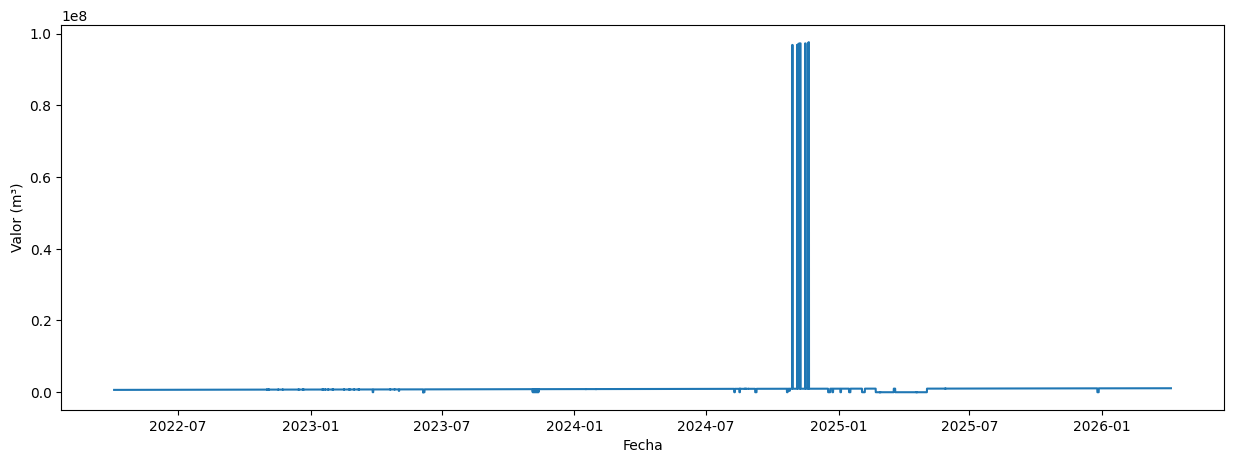

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df_raw_q['StartDateTime'], df_raw_q['Value'])
plt.xlabel('Fecha')
plt.ylabel('Valor (m³)')
plt.show()

In [ ]:
def corregir_anomalos_vecinos(df, col="Value"):
    # Aseguramos tipo numérico
    s = pd.to_numeric(df[col], errors="coerce")

    # 1. Detectar valores anómalos: 8 dígitos en la parte entera
    s_int = s.dropna().astype(int)
    mask_anom = s.index.isin(
        s_int[(s_int.astype(str).str.len() == 8)].index
    )

    # 2. Vecino válido hacia atrás y hacia adelante
    prev_valid = s.where(~mask_anom).ffill()
    next_valid = s.where(~mask_anom).bfill()

    # 3. Distancia a cada vecino
    dist_prev = (prev_valid - s).abs()
    dist_next = (next_valid - s).abs()

    # 4. Elegir el vecino más cercano
    replacement = np.where(dist_prev <= dist_next, prev_valid, next_valid)

    # 5. Sustituir solo los anómalos
    s_corrected = s.copy()
    s_corrected[mask_anom] = replacement[mask_anom]

    df[col] = s_corrected
    return df

df_raw_q = corregir_anomalos_vecinos(df_raw_q, col="Value")

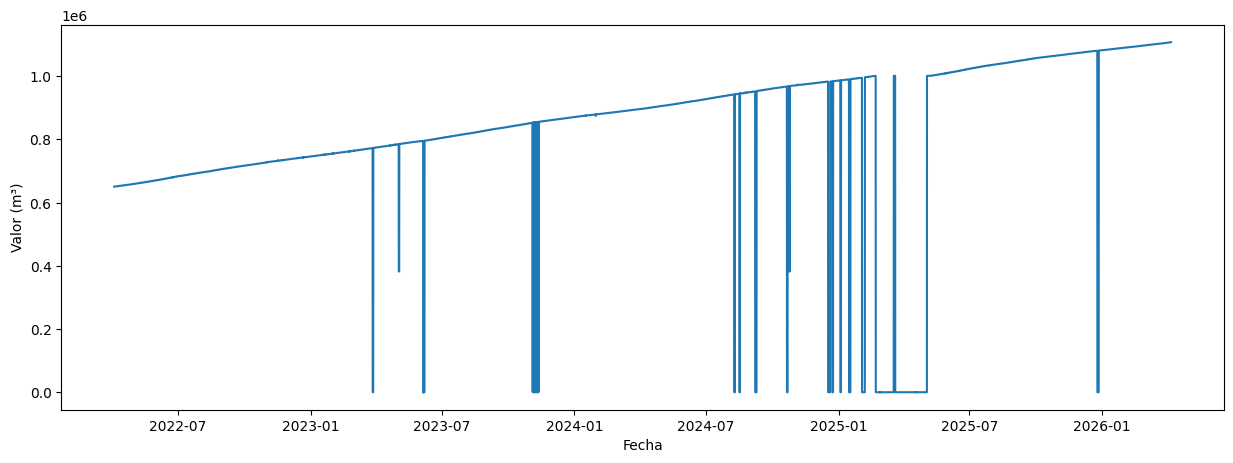

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df_raw_q['StartDateTime'], df_raw_q['Value'])
plt.xlabel('Fecha')
plt.ylabel('Valor (m³)')
plt.show()

In [ ]:
df_last = (df_raw_q.sort_values('StartDateTime').groupby(df_raw_q['StartDateTime'].dt.date).last().reset_index(drop=True))
df_last

,Value,StartDateTime
0,650361.0,2022-04-03 23:51:50
1,650705.0,2022-04-04 23:51:50
2,651008.0,2022-04-05 23:51:50
3,651309.0,2022-04-06 23:51:50
4,651636.0,2022-04-07 23:51:50
...,...,...
1460,1106151.0,2026-04-02 23:51:50
1461,1106447.0,2026-04-03 23:51:50
1462,1106696.0,2026-04-04 23:51:50
1463,1106962.0,2026-04-05 23:51:50


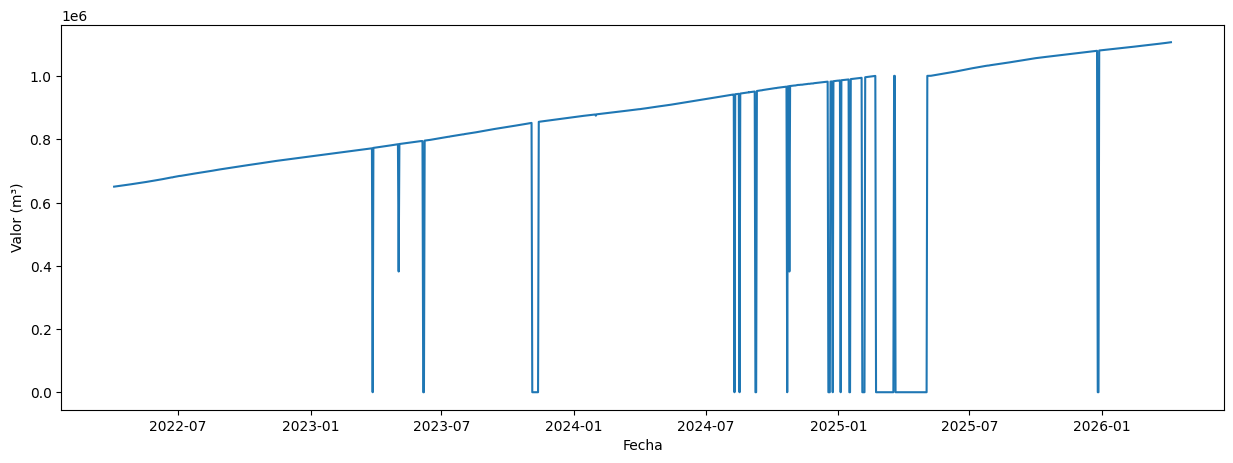

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df_last['StartDateTime'], df_last['Value'])
plt.xlabel('Fecha')
plt.ylabel('Valor (m³)')
plt.show()

In [ ]:
def restaurar_contador(df, col="Value"):
    """
    Restaura un contador acumulado estrictamente creciente.
    Detecta reinicios, ceros, NaN, valores repetidos, retrocesos y outliers.
    """

    df = df.copy()
    df[col] = pd.to_numeric(df[col], errors="coerce")

    v = df[col]

    # --- 1) Detectar valores inválidos ---
    mask_invalid = (
        v.isna() |
        (v == 0) |
        (v.diff() == 0) |                 # valores repetidos
        (v.diff() < 0) |                  # retrocesos
        (v < v.rolling(30, min_periods=1).median() * 0.5) |   # demasiado bajos
        (v > v.rolling(30, min_periods=1).median() * 2.0)     # demasiado altos
    )

    df.loc[mask_invalid, col] = np.nan

    # --- 2) Interpolación lineal ---
    df[col] = df[col].interpolate(
        method="linear",
        limit_direction="both"
    )

    # --- 3) Monotonicidad estricta ---
    df[col] = df[col].cummax()

    return df

In [ ]:
df_last = restaurar_contador(df_last, col="Value")

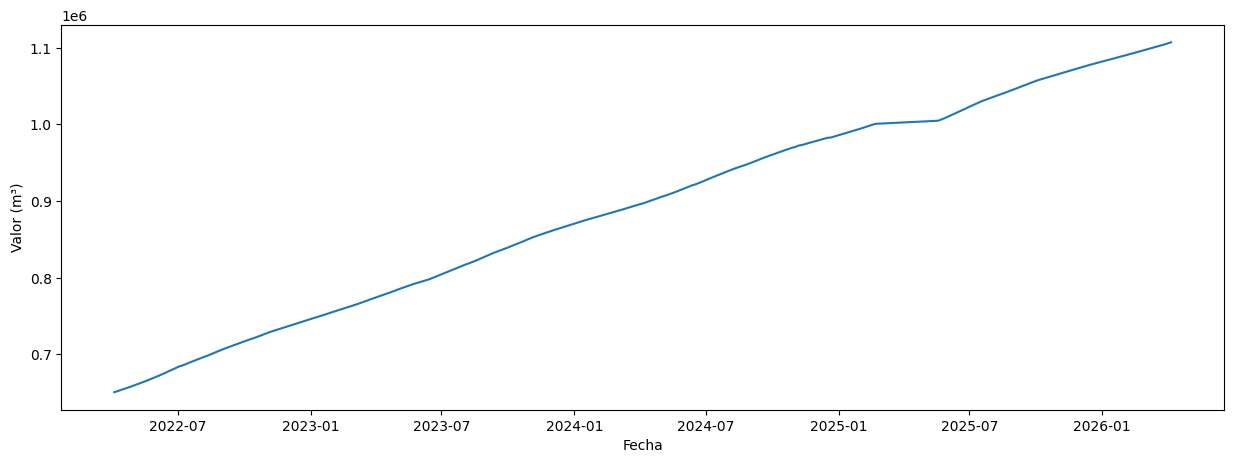

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df_last['StartDateTime'], df_last['Value'])
plt.xlabel('Fecha')
plt.ylabel('Valor (m³)')
plt.show()

In [ ]:

def corregir_serie(df,
                   start_bad="2025-02-20",
                   end_bad="2025-05-18"):

    df = df.copy()
    df["StartDateTime"] = pd.to_datetime(df["StartDateTime"])

    # 🔑 NORMALIZAR FECHAS (clave del fix)
    df["date"] = df["StartDateTime"].dt.normalize()
    df = df.sort_values("date").set_index("date")

    start_bad = pd.to_datetime(start_bad)
    end_bad = pd.to_datetime(end_bad)

    # Guardar original
    original = df["Value"].copy()

    # Día anterior al fallo
    day_before = start_bad - pd.Timedelta(days=1)
    prev_year_day = day_before - pd.DateOffset(years=1)

    # ⚠️ usar .loc con seguridad
    offset_year = original.loc[day_before] - original.loc[prev_year_day]

    # --- 1) Reconstrucción ---
    bad_range = pd.date_range(start_bad, end_bad, freq="D")

    for day in bad_range:
        ref_day = day - pd.DateOffset(years=1)

        # seguridad por si falta algún día
        if ref_day in original.index:
            df.loc[day, "Value"] = original.loc[ref_day] + offset_year

    # --- 2) Desplazamiento ---
    day_after = end_bad + pd.Timedelta(days=1)

    offset_shift = df.loc[end_bad, "Value"] - original.loc[end_bad]

    mask = df.index >= day_after
    df.loc[mask, "Value"] = original.loc[mask] + offset_shift

    return df.reset_index(drop=True)

df_last = corregir_serie(df_last)

In [ ]:
df_last

,Value,StartDateTime
0,650361.0,2022-04-03 23:51:50
1,650705.0,2022-04-04 23:51:50
2,651008.0,2022-04-05 23:51:50
3,651309.0,2022-04-06 23:51:50
4,651636.0,2022-04-07 23:51:50
...,...,...
1460,1129159.0,2026-04-02 23:51:50
1461,1129455.0,2026-04-03 23:51:50
1462,1129704.0,2026-04-04 23:51:50
1463,1129970.0,2026-04-05 23:51:50


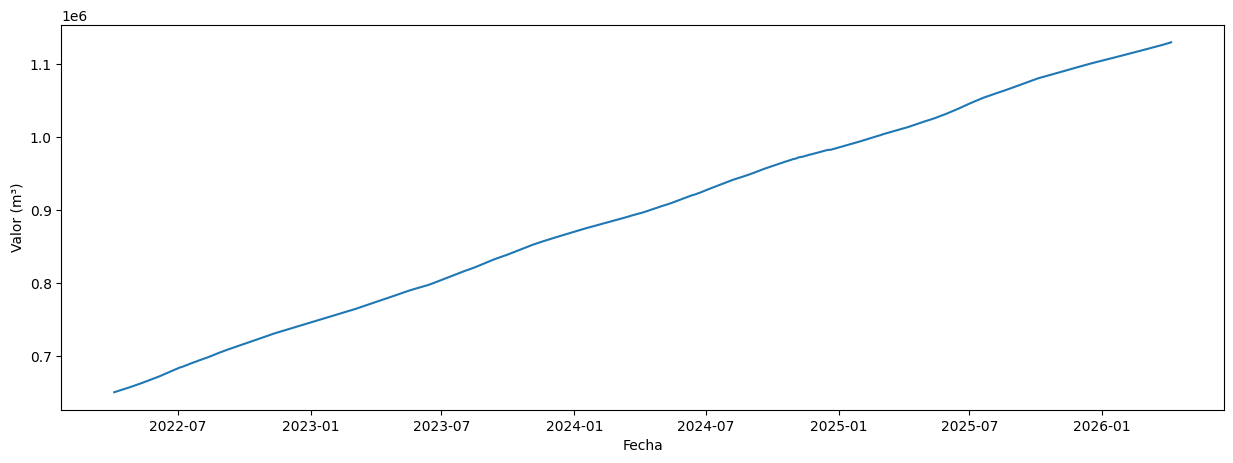

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df_last['StartDateTime'], df_last['Value'])
plt.xlabel('Fecha')
plt.ylabel('Valor (m³)')
plt.show()

In [ ]:
past_day_consumption = 0
daily_q = []

for index, item in df_last.iterrows():
    valor = item['Value']
    daily_q.append(valor - past_day_consumption)
    past_day_consumption = valor

df_daily = pd.DataFrame(index=df_last.index)
df_daily = df_last[['StartDateTime']].copy()
df_daily['Consumption'] = daily_q
df_daily


,StartDateTime,Consumption
0,2022-04-03 23:51:50,650361.0
1,2022-04-04 23:51:50,344.0
2,2022-04-05 23:51:50,303.0
3,2022-04-06 23:51:50,301.0
4,2022-04-07 23:51:50,327.0
...,...,...
1460,2026-04-02 23:51:50,284.0
1461,2026-04-03 23:51:50,296.0
1462,2026-04-04 23:51:50,249.0
1463,2026-04-05 23:51:50,266.0


In [ ]:
df_daily = df_daily.drop(df_daily.index[0])
df_daily = df_daily.drop(df_daily.index[-1])
df_daily

,StartDateTime,Consumption
1,2022-04-04 23:51:50,344.0
2,2022-04-05 23:51:50,303.0
3,2022-04-06 23:51:50,301.0
4,2022-04-07 23:51:50,327.0
5,2022-04-08 23:51:50,316.0
...,...,...
1459,2026-04-01 23:51:50,293.0
1460,2026-04-02 23:51:50,284.0
1461,2026-04-03 23:51:50,296.0
1462,2026-04-04 23:51:50,249.0


In [ ]:
fig = px.line(
    df_daily,
    y="Consumption",
    x="StartDateTime",
    markers=True,
    title="Consumo diario"
)

fig.update_layout(height=600, width=900)  # tamaño más grande
fig.show()


In [ ]:
def corregir_tramo_sierra(df, start_bad, end_bad, ventana_ref=14, fuerza=1.0):
    df = df.copy()
    df['StartDateTime'] = pd.to_datetime(df['StartDateTime'])
    df = df.sort_values('StartDateTime').reset_index(drop=True)

    df['inc'] = df['Consumption'].diff()

    # --- detectar tramo malo ---
    mask_bad = (
        (df['StartDateTime'] >= pd.to_datetime(start_bad)) &
        (df['StartDateTime'] <= pd.to_datetime(end_bad))
    )
    idx_bad = df[mask_bad].index

    if len(idx_bad) == 0:
        print("⚠️ No se detectó el tramo")
        return df

    idx_ini = idx_bad[0] - 1
    idx_fin = idx_bad[-1]

    val_ini = df.loc[idx_ini, 'Consumption']
    val_fin = df.loc[idx_fin, 'Consumption']

    n = len(idx_bad)

    # --- incremento medio necesario ---
    inc_mean = (val_fin - val_ini) / n

    # --- ventana buena anterior ---
    end_ref = df.loc[idx_ini, 'StartDateTime']
    start_ref = end_ref - pd.Timedelta(days=ventana_ref)

    inc_ref = df[
        (df['StartDateTime'] >= start_ref) &
        (df['StartDateTime'] < end_ref)
    ]['inc'].dropna().values

    # patrón real
    pattern = np.tile(inc_ref, int(np.ceil(n / len(inc_ref))))[:n]

    # centrar
    pattern_centered = pattern - pattern.mean()

    # escalar
    scale = np.std(pattern_centered)
    if scale == 0:
        scale = 1

    pattern_scaled = pattern_centered / scale

    amplitude = fuerza * np.std(inc_ref)
    pattern_final = pattern_scaled * amplitude

    # incrementos finales
    new_inc = inc_mean + pattern_final

    # --- reconstrucción DIRECTA ---
    for i, idx in enumerate(idx_bad):
        df.loc[idx, 'Consumption'] = df.loc[idx - 1, 'Consumption'] + new_inc[i]

    df = df.drop('inc', axis=1)

    return df

df_daily = corregir_tramo_sierra(
    df_daily,
    start_bad="2023-11-03",
    end_bad="2023-11-13",
    ventana_ref=14
)

In [ ]:
fig = px.line(
    df_daily,
    y="Consumption",
    x="StartDateTime",
    markers=True,
    title="Consumo diario"
)

fig.update_layout(height=600, width=900)  # tamaño más grande
fig.show()

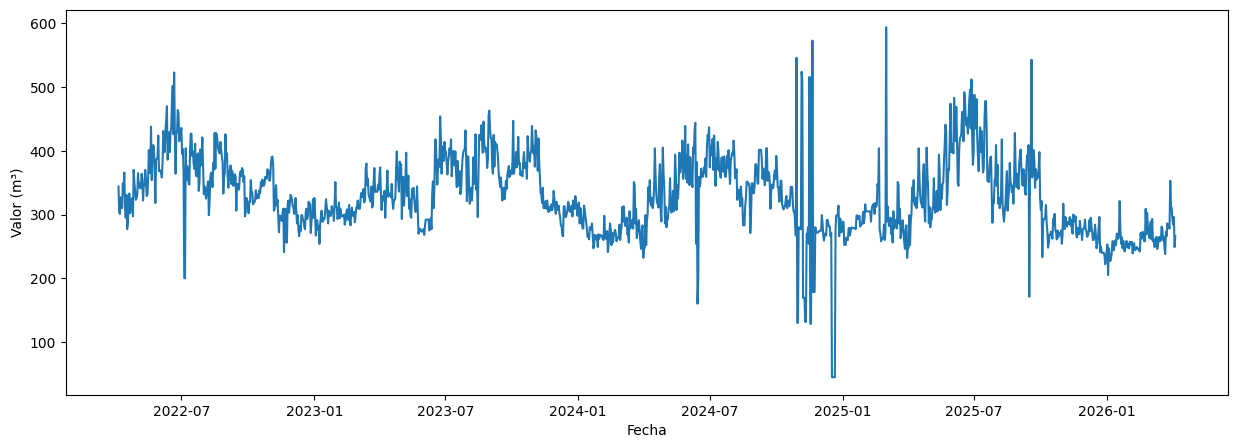

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df_daily['StartDateTime'], df_daily['Consumption'])
plt.xlabel('Fecha')
plt.ylabel('Valor (m³)')
plt.show()

In [ ]:
df_daily['StartDateTime'] = pd.to_datetime(df_daily['StartDateTime'])
df_daily_nuevo_indice = df_daily.set_index('StartDateTime')

In [ ]:
Q1=df_daily_nuevo_indice['Consumption'].quantile(0.25)
Q3=df_daily_nuevo_indice['Consumption'].quantile(0.75)
IQR=Q3-Q1
Lim_alto=Q3+1.5*IQR
Lim_bajo=Q3-1.5*IQR

print('Numero de outliers valor alto (mayores de ',Lim_alto,'): ',df_daily_nuevo_indice[df_daily_nuevo_indice.Consumption>Lim_alto].shape[0])
print('Indicación de las muestras con outliers (valor alto): ')
outliersIndex = df_daily_nuevo_indice[df_daily_nuevo_indice.Consumption>Lim_alto].index
print(df_daily_nuevo_indice[df_daily_nuevo_indice.Consumption>Lim_alto])

print('Numero de outliers valor bajo (menores de ',Lim_bajo,'):',df_daily_nuevo_indice[df_daily_nuevo_indice.Consumption<Lim_bajo].shape[0])
print('Indicación de las muestras con outliers (valor bajo): ')
print(df_daily_nuevo_indice[df_daily_nuevo_indice.Consumption<Lim_bajo])
outliersIndex = outliersIndex.append(df_daily_nuevo_indice[df_daily_nuevo_indice.Consumption<Lim_bajo].index)

Numero de outliers valor alto (mayores de  488.5 ):  12
Indicación de las muestras con outliers (valor alto): 
                     Consumption
StartDateTime                   
2022-06-18 23:51:50        502.0
2022-06-20 23:51:50        523.0
2024-10-28 23:51:50        546.0
2024-11-04 23:51:50        524.0
2024-11-05 23:51:50        510.0
2024-11-15 23:51:50        516.0
2024-11-19 23:51:50        573.0
2025-03-01 23:51:50        594.0
2025-06-17 23:51:50        492.0
2025-06-25 23:51:50        496.0
2025-06-27 23:51:50        512.0
2025-09-18 23:51:50        543.0
Numero de outliers valor bajo (menores de  245.5 ): 49
Indicación de las muestras con outliers (valor bajo): 
                     Consumption
StartDateTime                   
2022-07-04 23:51:50   200.000000
2022-07-05 23:51:50   200.000000
2022-11-19 23:51:50   241.000000
2024-02-10 23:51:50   241.000000
2024-03-30 23:51:50   232.000000
2024-06-13 23:51:50   160.000000
2024-06-14 23:51:50   196.000000
2024-10-29 23:51:50 

(0.0, 1000.0)

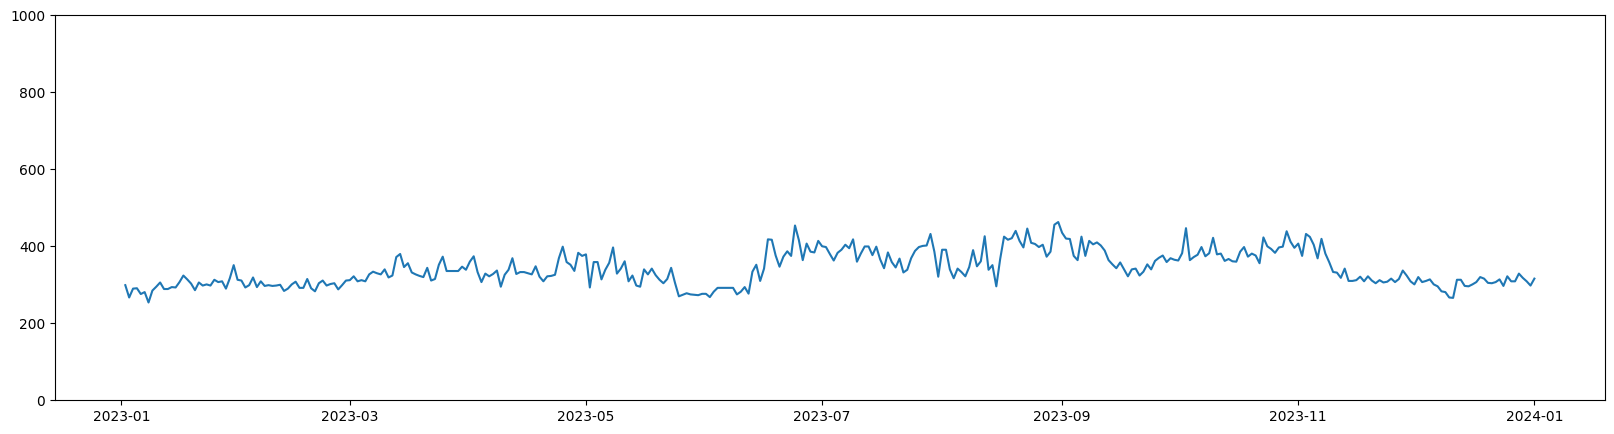

In [ ]:
#2023 es el más normal

df2023 = df_daily_nuevo_indice.loc['2023-01-01':'2023-12-31']
plt.figure(figsize=(20,5))
plt.plot(df2023['Consumption'])
plt.ylim([0,1000])

/tmp/ipykernel_760/495180509.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



<Axes: title={'center': 'Seasonal Mean (MSE: 370.38)'}, xlabel='StartDateTime'>

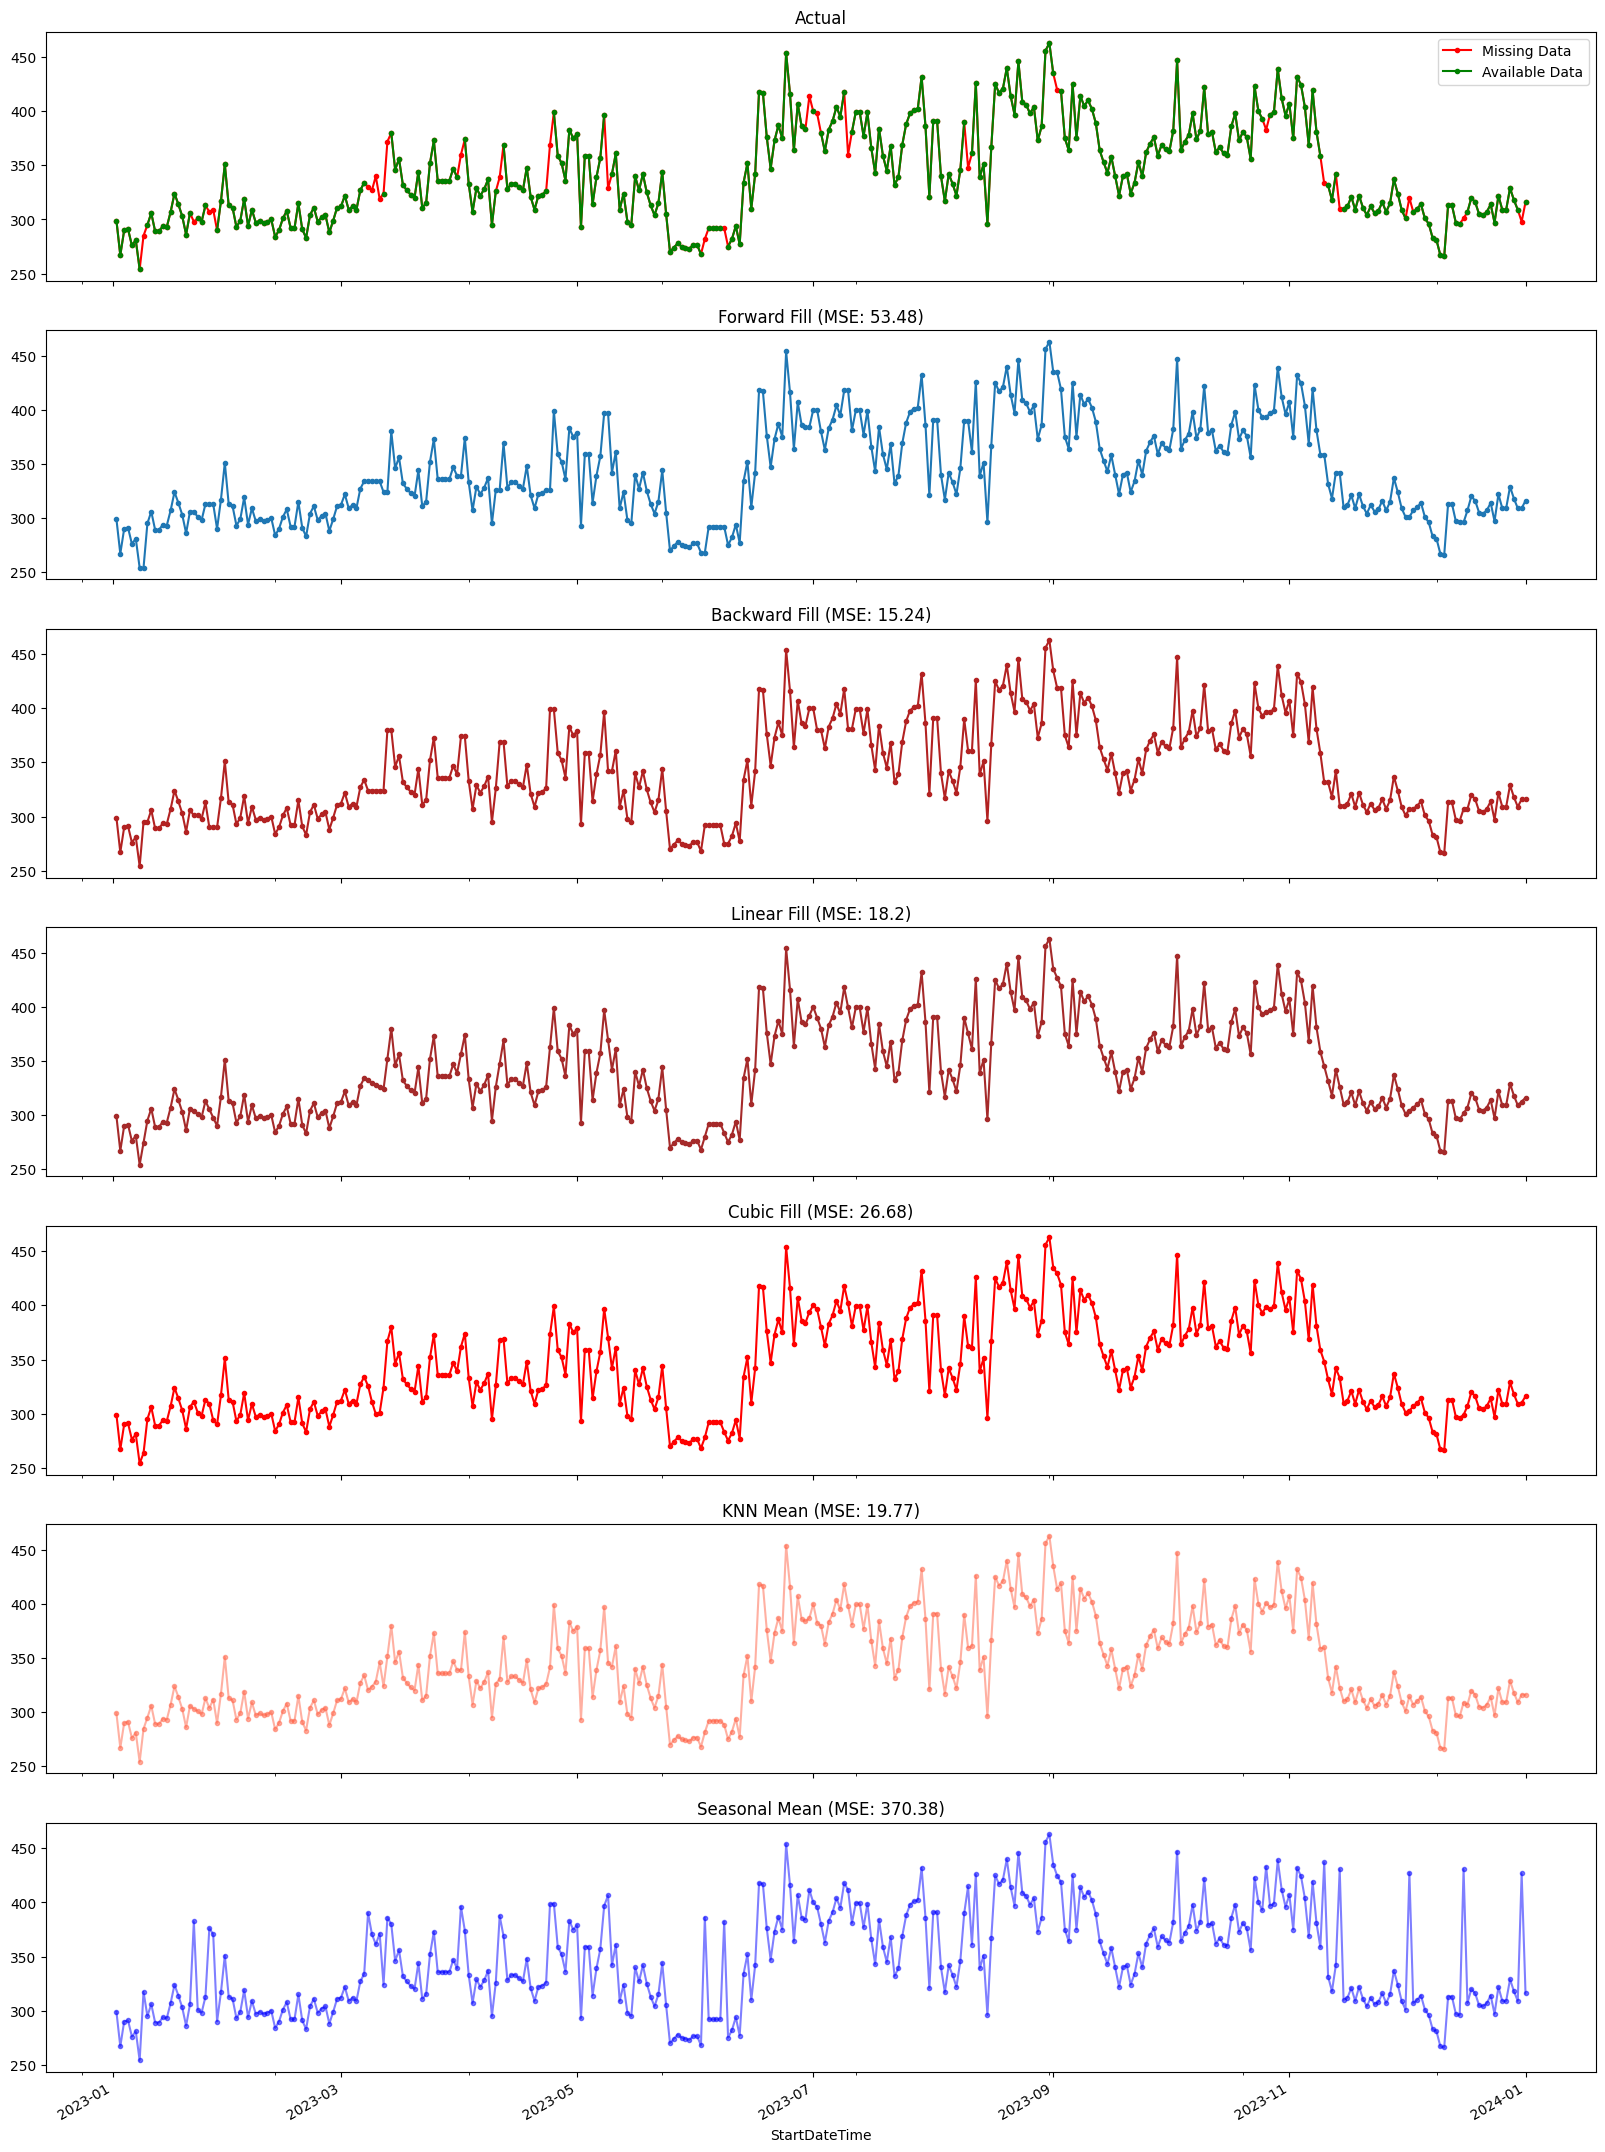

In [ ]:
np.random.seed(2)

####2)
df_orig = df2023
df_orig.rename(columns={'Consumption': 'Caudal'}, inplace=True)

df_valid_dates = df_orig.loc[~df_orig.index.isin(outliersIndex)].sample(frac = 0.07)
nan_valid = []
for index in df_orig.index:
    if index in df_valid_dates.index:
        nan_valid.append([True])
    else:
        nan_valid.append([False])

df = df_orig.mask(nan_valid)

fig, axes = plt.subplots(7, 1, sharex=True, figsize=(20, 30))
plt.rcParams.update({'xtick.bottom' : False})

####3)
## 1. Actual -------------------------------
df_orig.plot(title='Actual', ax=axes[0], label='Actual', color='red', style=".-")
df.plot(title='Actual', ax=axes[0], label='Actual', color='green', style=".-")
axes[0].legend(["Missing Data", "Available Data"])

## 2. Forward Fill --------------------------
df_ffill = df.ffill()
error = np.round(mean_squared_error(df_orig['Caudal'], df_ffill['Caudal']), 2)
df_ffill['Caudal'].plot(title='Forward Fill (MSE: ' + str(error) +")", ax=axes[1], label='Forward Fill', style=".-")

## 3. Backward Fill -------------------------
df_bfill = df.bfill()
error = np.round(mean_squared_error(df_orig['Caudal'], df_bfill['Caudal']), 2)
df_bfill['Caudal'].plot(title="Backward Fill (MSE: " + str(error) +")", ax=axes[2], label='Back Fill', color='firebrick', style=".-")

## 4. Linear Interpolation ------------------
df['rownum'] = np.arange(df.shape[0])
df_nona = df.dropna(subset = ['Caudal'])
f = interp1d(df_nona['rownum'], df_nona['Caudal'])
df['linear_fill'] = f(df['rownum'])
error = np.round(mean_squared_error(df_orig['Caudal'], df['linear_fill']), 2)
df['linear_fill'].plot(title="Linear Fill (MSE: " + str(error) +")", ax=axes[3], label='Linear Fill', color='brown', style=".-")

## 5. Cubic Interpolation --------------------
f2 = interp1d(df_nona['rownum'], df_nona['Caudal'], kind='cubic')
df['cubic_fill'] = f2(df['rownum'])
error = np.round(mean_squared_error(df_orig['Caudal'], df['cubic_fill']), 2)
df['cubic_fill'].plot(title="Cubic Fill (MSE: " + str(error) +")", ax=axes[4], label='Cubic Fill', color='red', style=".-")

## 6. Mean of 'n' Nearest Past Neighbors ------
def knn_mean(ts, n):
    out = np.copy(ts)
    for i, val in enumerate(ts):
        if np.isnan(val):
            n_by_2 = np.ceil(n/2)
            lower = np.max([0, int(i-n_by_2)])
            upper = np.min([len(ts)+1, int(i+n_by_2)])
            ts_near = np.concatenate([ts[lower:i], ts[i:upper]])
            out[i] = np.nanmean(ts_near)
    return out

df['knn_mean'] = knn_mean(df.Caudal, 8)
error = np.round(mean_squared_error(df_orig['Caudal'], df['knn_mean']), 2)
df['knn_mean'].plot(title="KNN Mean (MSE: " + str(error) +")", ax=axes[5], label='KNN Mean', color='tomato', alpha=0.5, style=".-")

## 7. Seasonal Mean ----------------------------
def seasonal_mean(ts, n, lr=0.7):
    """
    Compute the mean of corresponding seasonal periods
    ts: 1D array-like of the time series
    n: Seasonal window length of the time series
    """
    out = np.copy(ts)
    for i, val in enumerate(ts):
        if np.isnan(val):
            ts_seas = ts[i-1::-n]  # previous seasons only
            if np.isnan(np.nanmean(ts_seas)):
                ts_seas = np.concatenate([ts[i-1::-n], ts[i::n]])  # previous and forward
            out[i] = np.nanmean(ts_seas) * lr
    return out

df['seasonal_mean'] = seasonal_mean(df.Caudal, n=12, lr=1.25)
error = np.round(mean_squared_error(df_orig['Caudal'], df['seasonal_mean']), 2)
df['seasonal_mean'].plot(title="Seasonal Mean (MSE: " + str(error) +")", ax=axes[6], label='Seasonal Mean', color='blue', alpha=0.5, style=".-")

<Axes: title={'center': 'Linear Fill'}, xlabel='StartDateTime'>

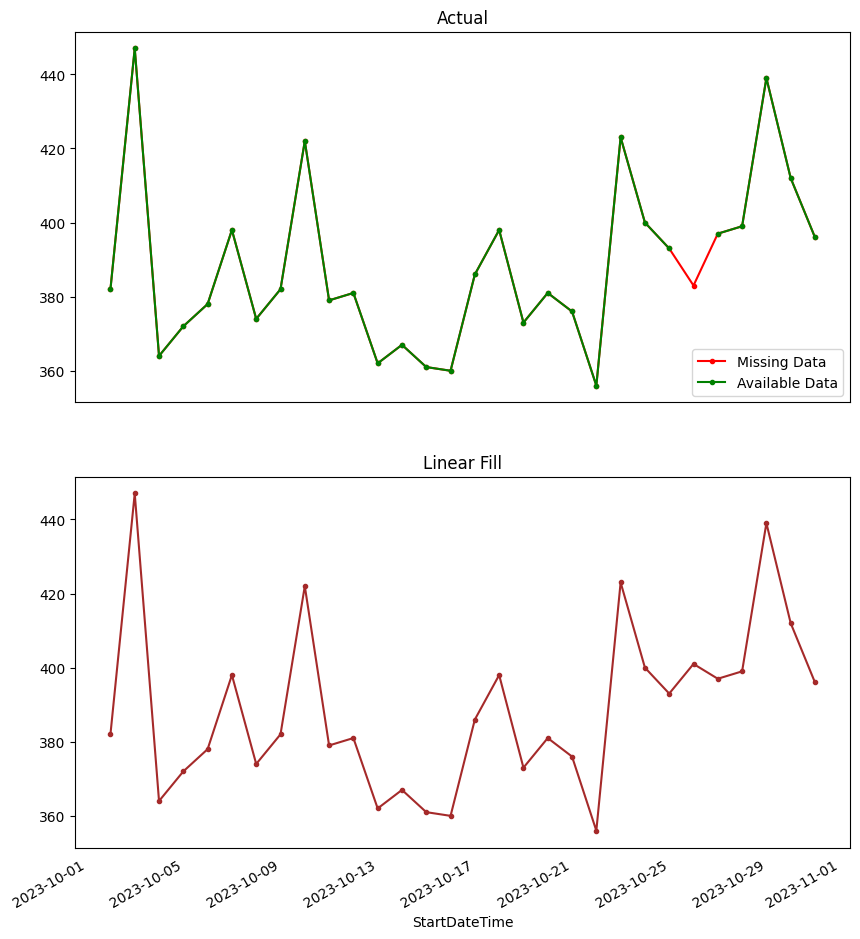

In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 12))
df_orig.loc['2023-10-01':'2023-10-30'].plot(title='Actual', ax=axes[0], label='Actual', color='red', style=".-")
df['Caudal'].loc['2023-10-01':'2023-10-30'].plot(title='Actual', ax=axes[0], label='Actual', color='green', style=".-")
axes[0].legend(["Missing Data", "Available Data"])
df['knn_mean'].loc['2023-10-01':'2023-10-30'].plot(title="Linear Fill", ax=axes[1], label='Linear Fill', color='brown', style=".-")

(200.0, 550.0)

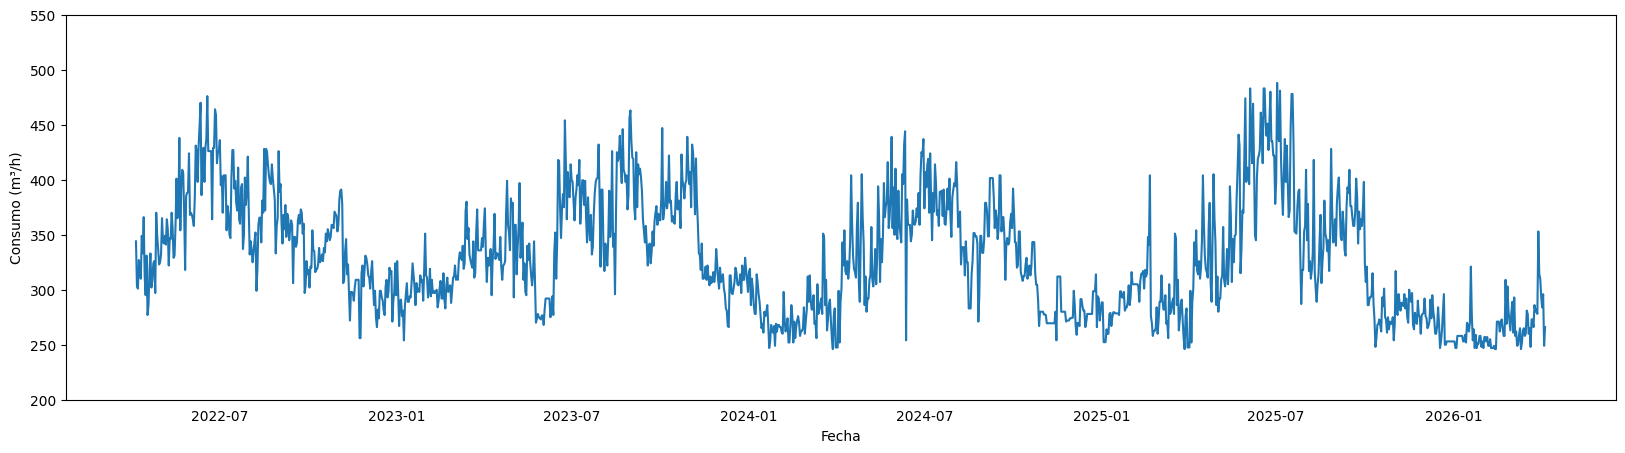

In [ ]:
df_daily_nuevo_indice.loc[outliersIndex, 'Consumption'] = np.nan
df_daily_nuevo_indice.loc[outliersIndex, 'Consumption'] = (
    df_daily_nuevo_indice['Consumption'].bfill().loc[outliersIndex]
)
plt.figure(figsize=(20,5))
plt.plot(df_daily_nuevo_indice['Consumption'])
plt.xlabel('Fecha')
plt.ylabel('Consumo (m³/h)')
plt.ylim([200,550])

In [ ]:
df_daily_nuevo_indice.to_csv('/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiarioAnálisis.csv')

In [ ]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    """
    Frame a time series as a supervised learning dataset.
    Produces the same output as the original implementation.
    """
    # Convertir a DataFrame
    df = pd.DataFrame(data)
    n_vars = df.shape[1]

    cols = []
    names = []

    # Secuencia de entrada (t-n ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        for j in range(n_vars):
            names.append(f"m3(t-{i})")

    # Secuencia de salida (t ... t+n)
    for i in range(n_out):
        cols.append(df.shift(-i))
        for j in range(n_vars):
            if i == 0:
                names.append("m3(t)")
            else:
                names.append(f"m3(t+{i})")

    # Concatenar
    agg = pd.concat(cols, axis=1)
    agg.columns = names

    # Eliminar NaN
    if dropnan:
        agg.dropna(inplace=True)

    # Índice como fecha (misma salida que tu versión)
    agg.index = pd.to_datetime(agg.index).date
    agg.index.name = "Fecha"

    return agg


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiarioAnálisis.csv', parse_dates=['StartDateTime'], index_col=['StartDateTime'])
df_7d_no_info = series_to_supervised(df,7,1)
df_14d_no_info = series_to_supervised(df,14,1)
df_7d_no_info.to_csv('/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_7d_no_info.csv')
df_14d_no_info.to_csv('/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_14d_no_info.csv')
df_7d_no_info

,m3(t-7),m3(t-6),m3(t-5),m3(t-4),m3(t-3),m3(t-2),m3(t-1),m3(t)
Fecha,,,,,,,,
2022-04-11,344.0,303.0,301.0,327.0,316.0,310.0,349.0,333.0
2022-04-12,303.0,301.0,327.0,316.0,310.0,349.0,333.0,366.0
2022-04-13,301.0,327.0,316.0,310.0,349.0,333.0,366.0,313.0
2022-04-14,327.0,316.0,310.0,349.0,333.0,366.0,313.0,295.0
2022-04-15,316.0,310.0,349.0,333.0,366.0,313.0,295.0,331.0
...,...,...,...,...,...,...,...,...
2026-04-01,286.0,280.0,282.0,278.0,353.0,314.0,310.0,293.0
2026-04-02,280.0,282.0,278.0,353.0,314.0,310.0,293.0,284.0
2026-04-03,282.0,278.0,353.0,314.0,310.0,293.0,284.0,296.0


In [ ]:
df_meteo = (pd.read_json("/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/tempAnalisis.json").assign(fecha=lambda d: pd.to_datetime(d["fecha"])).set_index("fecha")[["tmed", "tmax", "tmin", "prec", "hrMedia"]])

# Sustituir "Ip" por 0.0 y convertir comas a puntos
df_meteo = (df_meteo.replace("Ip", "0,0").replace(",", ".", regex=True).astype(float))
df_meteo


,tmed,tmax,tmin,prec,hrMedia
fecha,,,,,
2022-04-03,9.6,14.8,4.5,0.8,44.0
2022-04-04,9.5,10.9,8.1,3.2,79.0
2022-04-05,8.0,9.9,6.1,28.8,92.0
2022-04-06,11.8,18.5,5.0,0.0,63.0
2022-04-07,15.9,24.9,6.9,0.0,50.0
...,...,...,...,...,...
2026-04-02,17.2,23.5,10.9,0.0,33.0
2026-04-03,15.2,24.1,6.3,0.0,41.0
2026-04-04,16.2,24.6,7.9,0.0,46.0


In [ ]:
#www.borm.es
dias_festivos = [
    '2022-04-14','2022-04-15','2022-04-19','2022-05-02','2022-06-09',
    '2022-08-15','2022-09-13','2022-10-12','2022-11-01','2022-12-06',
    '2022-12-08','2022-12-26','2023-01-02','2023-01-06','2023-04-06',
    '2023-04-07','2023-04-11','2023-05-01','2023-06-09','2023-08-15',
    '2023-09-12','2023-10-12','2023-11-01','2023-12-06','2023-12-08',
    '2023-12-25','2024-01-01','2024-01-06','2024-03-19','2024-03-28',
    '2024-03-29','2024-04-02','2024-05-01','2024-08-15','2024-09-17',
    '2024-10-12','2024-11-01','2024-12-06','2024-12-09','2024-12-25',
    '2025-01-01','2025-01-06','2025-03-19','2025-04-17','2025-04-18',
    '2025-04-22','2025-05-01','2025-06-09','2025-08-15','2025-09-16',
    '2025-11-01','2025-12-06','2025-12-08','2025-12-25','2026-01-01',
    '2026-01-06','2026-03-19','2026-04-02','2026-04-03'
]


In [ ]:
df_7d_info = df_7d_no_info.copy()

df_7d_info['DateTime'] = df_7d_info.index

df_7d_info['Dia_semana'] = df_7d_info['DateTime'].apply(lambda x: x.weekday()) # Día de la semana
df_7d_info['Dia_mes'] = df_7d_info['DateTime'].apply(lambda x: x.day) # Día del mes
df_7d_info['Mes'] = df_7d_info['DateTime'].apply(lambda x: x.month) # Día del mes
df_7d_info['Fin_de_semana']=0
df_7d_info.loc[df_7d_info.Dia_semana >= 5, 'Fin_de_semana'] = 1
df_7d_info = df_7d_info.drop(['DateTime'],axis=1)

df_7d_info['Festivo'] = 0

for dia in dias_festivos:
    date = datetime.strptime(dia,'%Y-%m-%d').date()
    df_7d_info.loc[date,'Festivo']=1

df_7d_info = df_7d_info.dropna()

# DATOS CLIMÁTICOS
df_7d_info['Tmed'] = df_meteo.loc[df_7d_info.index[0]:df_7d_info.index[-1]:,'tmed']          # Temperatura media
df_7d_info['Tmin'] = df_meteo.loc[df_7d_info.index[0]:df_7d_info.index[-1]:,'tmin']          # Temperatura máxima
df_7d_info['Tmax'] = df_meteo.loc[df_7d_info.index[0]:df_7d_info.index[-1]:,'tmax']          # Temperatura máxima
df_7d_info['Prec'] = df_meteo.loc[df_7d_info.index[0]:df_7d_info.index[-1]:,'prec']    # Precipitación
df_7d_info['HRmed'] = df_meteo.loc[df_7d_info.index[0]:df_7d_info.index[-1]:,'hrMedia']    # Humedad Relativa media

df_7d_info = df_7d_info.astype({'Dia_semana': 'int8', 'Dia_mes': 'int8',
                                'Mes': 'int8', 'Fin_de_semana': 'int8', 'Festivo': 'int8'})
display(df_7d_info.head())


,m3(t-7),m3(t-6),m3(t-5),m3(t-4),m3(t-3),m3(t-2),m3(t-1),m3(t),Dia_semana,Dia_mes,Mes,Fin_de_semana,Festivo,Tmed,Tmin,Tmax,Prec,HRmed
Fecha,,,,,,,,,,,,,,,,,,
2022-04-11,344.0,303.0,301.0,327.0,316.0,310.0,349.0,333.0,0,11,4,0,0,15.1,10.3,19.9,0.0,73.0
2022-04-12,303.0,301.0,327.0,316.0,310.0,349.0,333.0,366.0,1,12,4,0,0,15.6,12.7,18.4,19.2,84.0
2022-04-13,301.0,327.0,316.0,310.0,349.0,333.0,366.0,313.0,2,13,4,0,0,15.6,11.1,20.1,9.2,82.0
2022-04-14,327.0,316.0,310.0,349.0,333.0,366.0,313.0,295.0,3,14,4,0,1,18.0,14.2,21.8,0.0,57.0
2022-04-15,316.0,310.0,349.0,333.0,366.0,313.0,295.0,331.0,4,15,4,0,1,19.2,13.6,24.9,0.0,46.0


In [ ]:
df_14d_info = df_14d_no_info.copy()

df_14d_info['DateTime'] = df_14d_info.index

df_14d_info['Dia_semana'] = df_14d_info['DateTime'].apply(lambda x: x.weekday()) # Día de la semana
df_14d_info['Dia_mes'] = df_14d_info['DateTime'].apply(lambda x: x.day) # Día del mes
df_14d_info['Mes'] = df_14d_info['DateTime'].apply(lambda x: x.month) # Día del mes
df_14d_info['Fin_de_semana']=0
df_14d_info.loc[df_14d_info.Dia_semana >= 5, 'Fin_de_semana'] = 1
df_14d_info = df_14d_info.drop(['DateTime'],axis=1)

df_14d_info['Festivo'] = 0

for dia in dias_festivos:
    date = datetime.strptime(dia,'%Y-%m-%d').date()
    df_14d_info.loc[date,'Festivo']=1

df_14d_info = df_14d_info.dropna()

# DATOS CLIMÁTICOS
df_14d_info['Tmed'] = df_meteo.loc[df_14d_info.index[0]:df_14d_info.index[-1]:,'tmed']          # Temperatura media
df_14d_info['Tmin'] = df_meteo.loc[df_14d_info.index[0]:df_14d_info.index[-1]:,'tmin']          # Temperatura máxima
df_14d_info['Tmax'] = df_meteo.loc[df_14d_info.index[0]:df_14d_info.index[-1]:,'tmax']          # Temperatura máxima
df_14d_info['Prec'] = df_meteo.loc[df_14d_info.index[0]:df_14d_info.index[-1]:,'prec']    # Precipitación
df_14d_info['HRmed'] = df_meteo.loc[df_14d_info.index[0]:df_14d_info.index[-1]:,'hrMedia']    # Humedad Relativa media

df_14d_info = df_14d_info.astype({'Dia_semana': 'int8', 'Dia_mes': 'int8',
                                'Mes': 'int8', 'Fin_de_semana': 'int8', 'Festivo': 'int8'})
display(df_14d_info.head())

,m3(t-14),m3(t-13),m3(t-12),m3(t-11),m3(t-10),m3(t-9),m3(t-8),m3(t-7),m3(t-6),m3(t-5),...,Dia_semana,Dia_mes,Mes,Fin_de_semana,Festivo,Tmed,Tmin,Tmax,Prec,HRmed
Fecha,,,,,,,,,,,,,,,,,,,,,
2022-04-18,344.0,303.0,301.0,327.0,316.0,310.0,349.0,333.0,366.0,313.0,...,0,18,4,0,0,19.0,12.6,25.4,2.2,64.0
2022-04-19,303.0,301.0,327.0,316.0,310.0,349.0,333.0,366.0,313.0,295.0,...,1,19,4,0,1,18.6,13.1,24.0,0.2,76.0
2022-04-20,301.0,327.0,316.0,310.0,349.0,333.0,366.0,313.0,295.0,331.0,...,2,20,4,0,0,12.6,10.1,15.2,8.6,72.0
2022-04-21,327.0,316.0,310.0,349.0,333.0,366.0,313.0,295.0,331.0,277.0,...,3,21,4,0,0,16.6,11.1,22.1,0.0,41.0
2022-04-22,316.0,310.0,349.0,333.0,366.0,313.0,295.0,331.0,277.0,286.0,...,4,22,4,0,0,14.7,9.2,20.2,1.0,60.0


<Axes: >

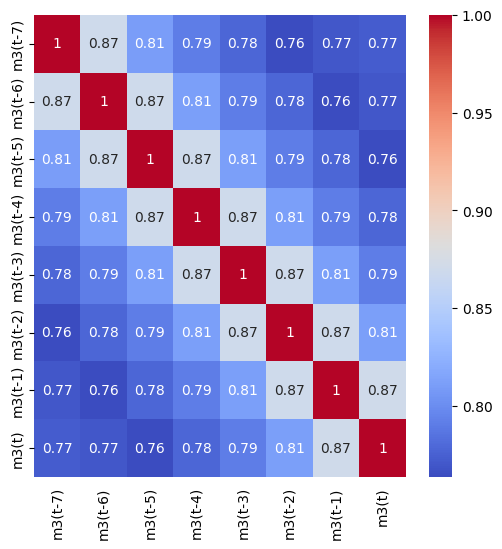

In [ ]:
plt.rcParams["figure.figsize"] = (6,6)
matriz_corr = df_7d_no_info.corr()
sns.heatmap(matriz_corr, annot = True, cmap = "coolwarm")

<Axes: >

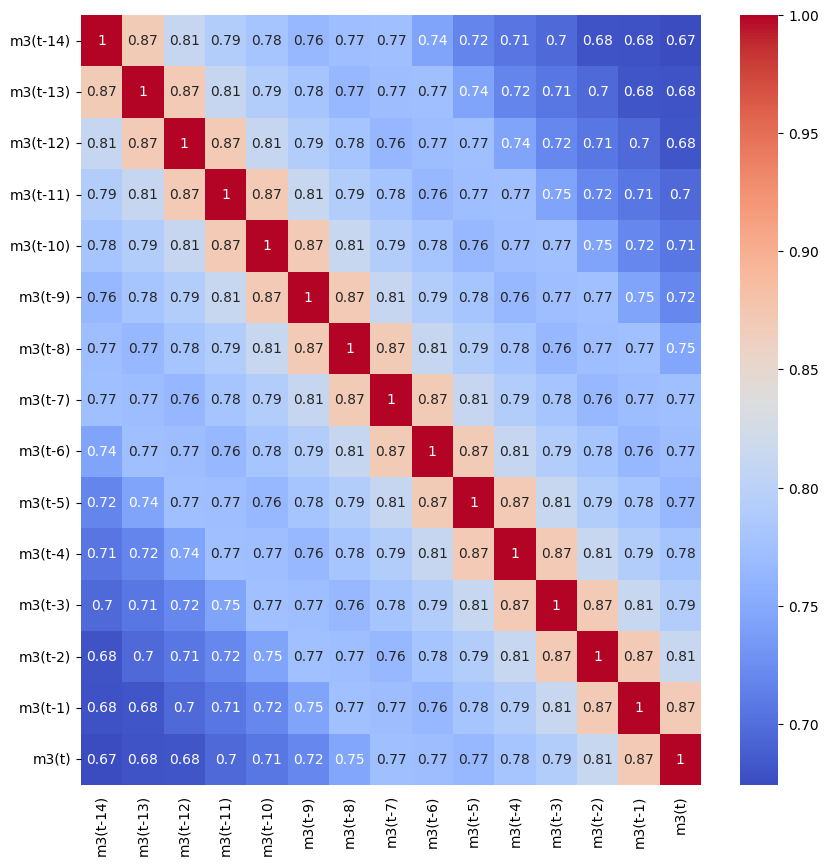

In [ ]:
plt.rcParams["figure.figsize"] = (10,10)
matriz_corr = df_14d_no_info.corr()
sns.heatmap(matriz_corr, annot = True, cmap = "coolwarm")

<Axes: >

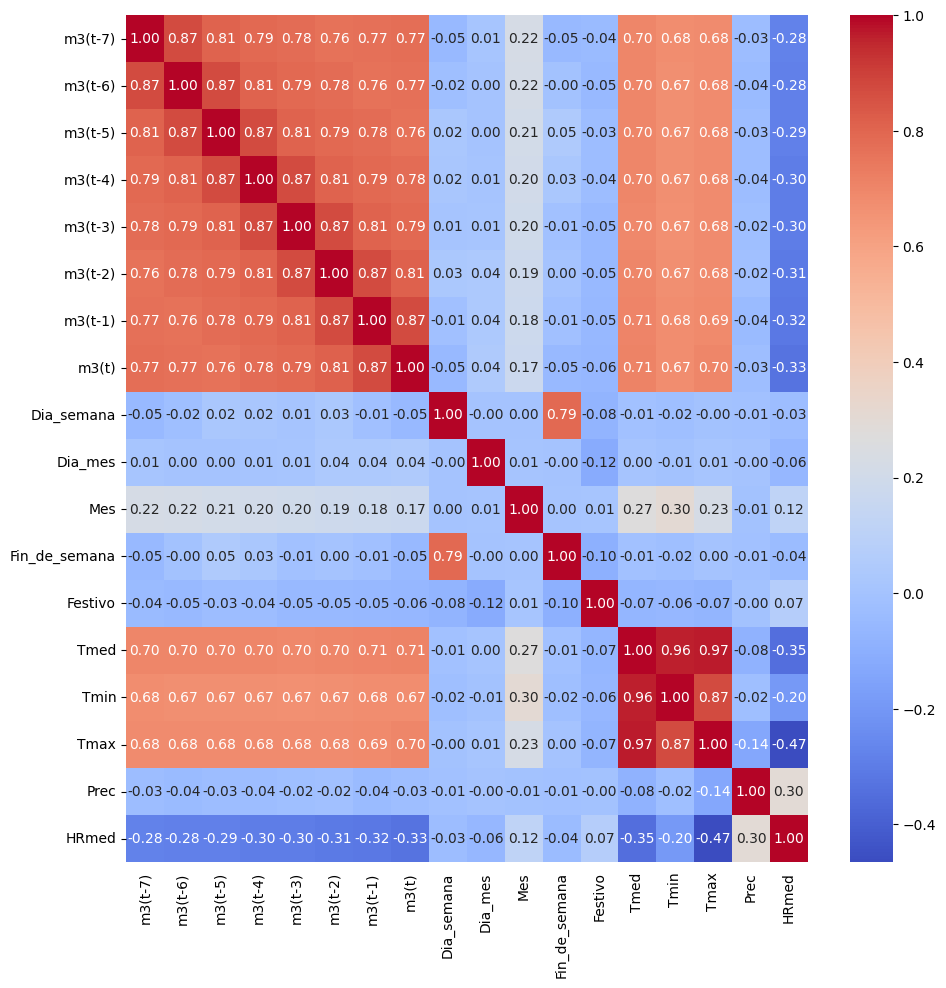

In [ ]:
plt.rcParams["figure.figsize"] = (11,11)
matriz_corr = df_7d_info.corr()
sns.heatmap(matriz_corr, annot = True, cmap = "coolwarm", fmt='.2f')

<Axes: >

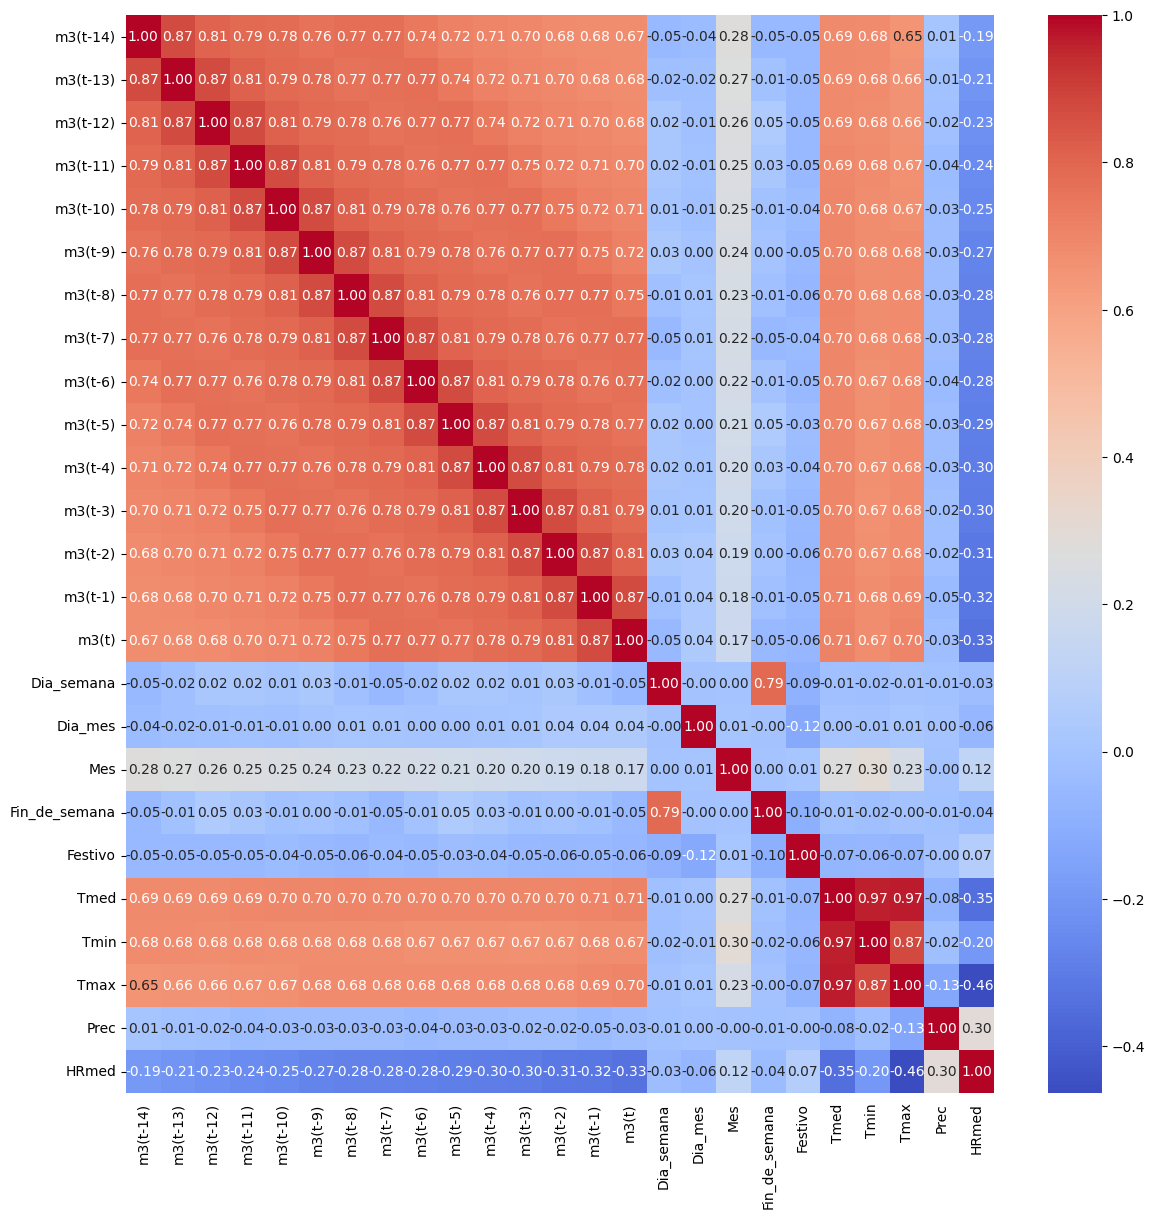

In [ ]:
plt.rcParams["figure.figsize"] = (14,14)
matriz_corr = df_14d_info.corr()
sns.heatmap(matriz_corr, annot = True, cmap = "coolwarm", fmt='.2f')

In [ ]:
df_7d_info = df_7d_info.drop(['Dia_mes','Festivo'], axis=1)
df_7d_info.to_csv('/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_7d_info.csv')
df_14d_info = df_14d_info.drop(['Dia_mes','Festivo'], axis=1)
df_14d_info.to_csv('/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiario_14d_info.csv')